# NASA Bearing Dataset

Here I will explore and analysis the bearing dataset. I also bulit a NN model at the end to learn the NASA data. 

In [4]:
import pandas as pd
import numpy as np
from pathlib import Path
from matplotlib import pyplot as plt
import os
from tqdm import tqdm
from scipy.spatial.distance import mahalanobis

from sklearn.metrics import recall_score, f1_score, precision_recall_curve,confusion_matrix, roc_auc_score, precision_score
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam

from imblearn.over_sampling import SMOTE

from matplotlib.ticker import MaxNLocator


import sys
sys.path.append("../")

2025-02-26 11:22:21.932267: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [5]:
data_folder = "/Users/heinliao/Desktop/Womanium_Quantum_AI_2024/WQSL_Fraunhofer/Code/womanium/data_preprocessing/NASA/dataset_2/2nd_test/2nd_test"

print("Changed working directory to:", os.getcwd())

Changed working directory to: /Users/heinliao/Desktop/Womanium_Quantum_AI_2024/WQSL_Fraunhofer/Code/womanium/data_preprocessing/NASA


In [6]:
df_an = pd.read_csv('combined_dataset2.csv')

(array([12460., 12462., 12464., 12466., 12468.]),
 [Text(12460.0, 0, '2004-02-12'),
  Text(12462.0, 0, '2004-02-14'),
  Text(12464.0, 0, '2004-02-16'),
  Text(12466.0, 0, '2004-02-18'),
  Text(12468.0, 0, '2004-02-20')])

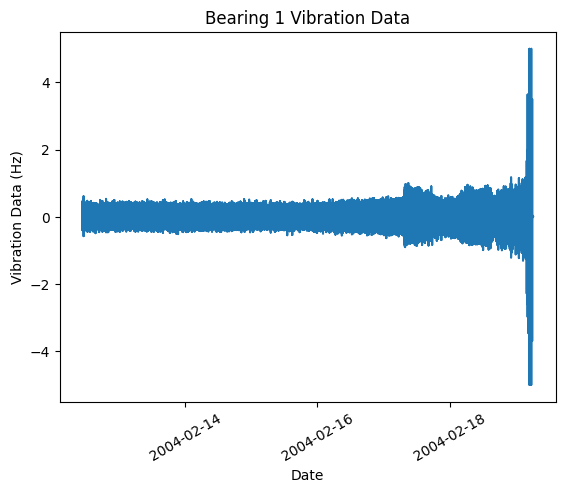

In [7]:
#fig,ax = plt.subplots(1,1, figsize=(10,8))

df_an['File'] = pd.to_datetime(df_an['File'], format="%Y.%m.%d.%H.%M.%S")

plt.plot(df_an['File'], df_an['Bearing1'])

plt.ylabel('Vibration Data (Hz)')
plt.xlabel('Date')
plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=5))
#plt.grid(alpha=0.5)
plt.title("Bearing 1 Vibration Data")
plt.xticks(rotation=30)
# according to kaggle, bearing 1 faced an "outer race failure"

In [8]:
df_an.head()

,Bearing1,Bearing2,Bearing3,Bearing4,File
0,-0.049,-0.071,-0.132,-0.010,2004-02-12 10:32:39
1,-0.042,-0.073,-0.007,-0.105,2004-02-12 10:32:39
2,0.015,0.000,0.007,0.000,2004-02-12 10:32:39
3,-0.051,0.020,-0.002,0.100,2004-02-12 10:32:39
4,-0.107,0.010,0.127,0.054,2004-02-12 10:32:39


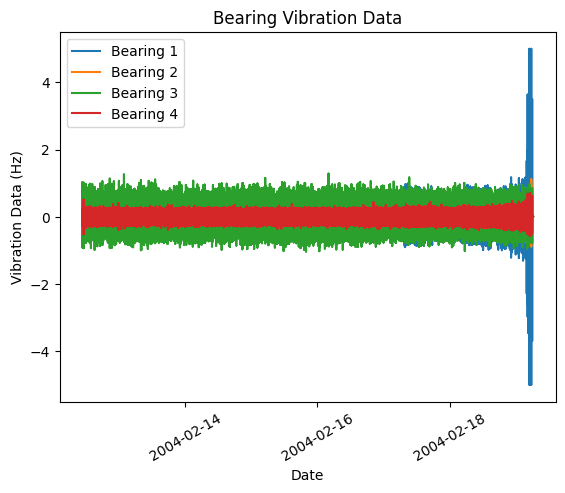

In [9]:
plt.plot(df_an['File'], df_an['Bearing1'], label='Bearing 1')
plt.plot(df_an['File'], df_an['Bearing2'], label='Bearing 2')
plt.plot(df_an['File'], df_an['Bearing3'], label='Bearing 3')
plt.plot(df_an['File'], df_an['Bearing4'], label='Bearing 4')
plt.title('Bearing Vibration Data')
plt.ylabel('Vibration Data (Hz)')
plt.xlabel('Date')

plt.gca().xaxis.set_major_locator(MaxNLocator(nbins=5))
#plt.grid(alpha=0.5)

plt.xticks(rotation=30)
plt.legend(loc='upper left')



In [10]:
df_an.head()

,Bearing1,Bearing2,Bearing3,Bearing4,File
0,-0.049,-0.071,-0.132,-0.010,2004-02-12 10:32:39
1,-0.042,-0.073,-0.007,-0.105,2004-02-12 10:32:39
2,0.015,0.000,0.007,0.000,2004-02-12 10:32:39
3,-0.051,0.020,-0.002,0.100,2004-02-12 10:32:39
4,-0.107,0.010,0.127,0.054,2004-02-12 10:32:39


In [11]:
# Group by the 'File' column and calculate RMS for each bearing
bearing_rms = (
    df_an.groupby('File')
    .apply(lambda group: (group.iloc[:, :-1]**2).mean()**0.5)  # Exclude 'File' column
)

bearing_rms = bearing_rms.reset_index()
bearing_rms.columns = ['File'] + [f'RMS Bearing {i+1}'for i in range(bearing_rms.shape[1]-1)]

# df_merged = pd.merge(df_an, rms_over_time, on='File', how='left')

# # Reset index to make it easier to work with
# df_merged.head()

bearing_rms.head()


/var/folders/cj/40cyks_j6mv5v7z15qnhwj7h0000gn/T/ipykernel_8716/1351496038.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda group: (group.iloc[:, :-1]**2).mean()**0.5)  # Exclude 'File' column


,File,RMS Bearing 1,RMS Bearing 2,RMS Bearing 3,RMS Bearing 4
0,2004-02-12 10:32:39,0.074179,0.090944,0.109404,0.054103
1,2004-02-12 10:42:39,0.075382,0.093419,0.109817,0.056101
2,2004-02-12 10:52:39,0.076230,0.093718,0.109861,0.056145
3,2004-02-12 11:02:39,0.078724,0.092947,0.110667,0.056807
4,2004-02-12 11:12:39,0.078474,0.095348,0.107506,0.056841


In [12]:
df_test = bearing_rms.copy()

df_test = df_test.reset_index()
df_test.columns = ['File'] + [f"RMS bearing {i+1}" for i in range(df_test.shape[1]-1)]

df_test.iloc[:,1:] = df_test.iloc[:,1:].apply(pd.to_numeric, errors='coerce')

min_max = df_test.iloc[:, 1:].apply(lambda col: (col - col.min()) / (col.max() - col.min()), axis=0)
df_test_norm = pd.concat([df_test['File'], min_max], axis=1)






/var/folders/cj/40cyks_j6mv5v7z15qnhwj7h0000gn/T/ipykernel_8716/4191173741.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0      1076581959000000000
1      1076582559000000000
2      1076583159000000000
3      1076583759000000000
4      1076584359000000000
              ...         
979    1077169359000000000
980    1077169959000000000
981    1077170559000000000
982    1077171159000000000
983    1077171759000000000
Name: RMS bearing 1, Length: 984, dtype: int64' has dtype incompatible with datetime64[ns], please explicitly cast to a compatible dtype first.
  df_test.iloc[:,1:] = df_test.iloc[:,1:].apply(pd.to_numeric, errors='coerce')


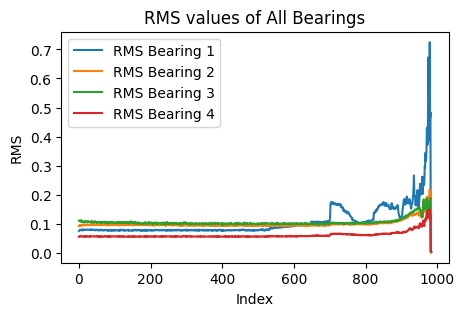

In [13]:
# Plot RMS for each bearing
plt.figure(figsize=(5, 3))
for column in bearing_rms.columns[1:5]:  # Skip 'File' column
    plt.plot( bearing_rms[column], label=column)
    plt.ylabel('RMS')
    plt.xlabel('Index')

#plt.grid(alpha=0.5)
plt.title("RMS values of All Bearings")
plt.legend()

plt.show()


## Mahalanobis Distance

The Mahalanobis distance is a measure of how far a data point is from the mean of a distribution, considering the the correlation between features. 

$$D_M(x) = \sqrt{(x-\mu)^T \Sigma^{-1}(x-\mu)} $$

where:
- $x$ is the data point
- $\mu$ is the mean vector
- $\Sigma$ is the covariance matrix and $\Sigma^{-1}$ is the inverse cov matrix
- $x - \mu$ is the deviation vector

The mean vector and covariance matrix are computed using the RMS values of all the bearings. When calculating for the mean and covariance of the data, I will use the first 400 index because these data points are the "normal" data points that would identify the anomalies

In [ ]:
rms_cols = [f'RMS Bearing {i}' for i in range(1,5)]
bearing_data = bearing_rms[rms_cols].values

baseline_data = bearing_data[:400]

mean_bearing = np.mean(baseline_data, axis=0)
cov_bearing = np.cov(baseline_data, rowvar=False)

inv_cov_bearing = np.linalg.inv(cov_bearing)

bearing_rms[f'MDistance'] = [mahalanobis(row, mean_bearing, inv_cov_bearing) for row in bearing_data]

bearing_rms.head()

,File,RMS Bearing 1,RMS Bearing 2,RMS Bearing 3,RMS Bearing 4,MDistance
0,2004-02-12 10:32:39,0.074179,0.090944,0.109404,0.054103,6.441805
1,2004-02-12 10:42:39,0.075382,0.093419,0.109817,0.056101,4.738613
2,2004-02-12 10:52:39,0.076230,0.093718,0.109861,0.056145,4.225557
3,2004-02-12 11:02:39,0.078724,0.092947,0.110667,0.056807,5.190883
4,2004-02-12 11:12:39,0.078474,0.095348,0.107506,0.056841,2.762168


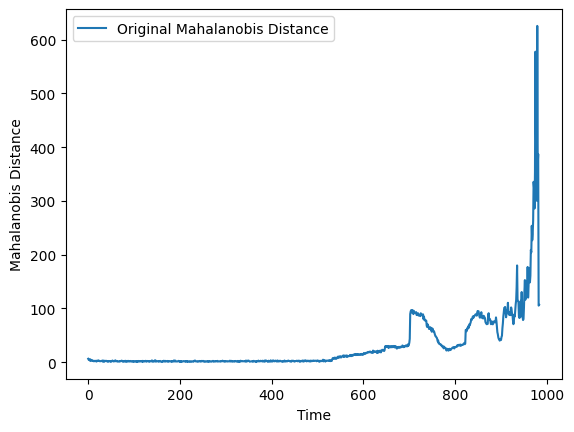

In [15]:
plt.plot(bearing_rms['MDistance'], label='Original Mahalanobis Distance')
#plt.plot(bearing_rms['gaussian_MDistance'], label='Smoothed Mahalanobis Distance', linewidth=2)
plt.xlabel('Time')
plt.ylabel('Mahalanobis Distance')
plt.legend()
plt.show()

In [16]:
mdistance = np.zeros(len(bearing_data))
window_size = 100


threshold_percentile = 90
threshold_value = np.percentile(bearing_rms['MDistance'], threshold_percentile)

filtered_data = bearing_rms[bearing_rms['MDistance'] <= threshold_value]



In [17]:
bearing_rms.head()

,File,RMS Bearing 1,RMS Bearing 2,RMS Bearing 3,RMS Bearing 4,MDistance
0,2004-02-12 10:32:39,0.074179,0.090944,0.109404,0.054103,6.441805
1,2004-02-12 10:42:39,0.075382,0.093419,0.109817,0.056101,4.738613
2,2004-02-12 10:52:39,0.076230,0.093718,0.109861,0.056145,4.225557
3,2004-02-12 11:02:39,0.078724,0.092947,0.110667,0.056807,5.190883
4,2004-02-12 11:12:39,0.078474,0.095348,0.107506,0.056841,2.762168


In [ ]:
from scipy.stats import chi2

healthy_mdistance = filtered_data['MDistance']#[0:600]
print(healthy_mdistance)
threshold = np.mean(healthy_mdistance)#10 # arbitrary threshold. 
print(f'Threshold : {threshold}')


bearing_rms['failure'] = bearing_rms['MDistance'] > threshold

bearing_rms.head()


0       6.441805
1       4.738613
2       4.225557
3       5.190883
4       2.762168
         ...    
940    82.329861
942    83.700361
947    84.103468
948    78.430535
949    80.437697
Name: MDistance, Length: 885, dtype: float64
Threshold : 16.742203442665556


,File,RMS Bearing 1,RMS Bearing 2,RMS Bearing 3,RMS Bearing 4,MDistance,failure
0,2004-02-12 10:32:39,0.074179,0.090944,0.109404,0.054103,6.441805,False
1,2004-02-12 10:42:39,0.075382,0.093419,0.109817,0.056101,4.738613,False
2,2004-02-12 10:52:39,0.076230,0.093718,0.109861,0.056145,4.225557,False
3,2004-02-12 11:02:39,0.078724,0.092947,0.110667,0.056807,5.190883,False
4,2004-02-12 11:12:39,0.078474,0.095348,0.107506,0.056841,2.762168,False


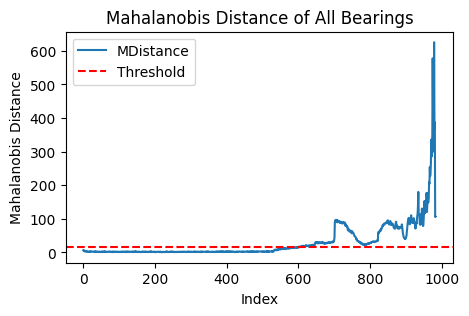

In [19]:
plt.figure(figsize=(5,3))
plt.plot(bearing_rms['MDistance'], label='MDistance')
plt.axhline(y=threshold, color='r', linestyle='--', label='Threshold')
plt.xlabel('Index')
plt.ylabel('Mahalanobis Distance')
plt.title("Mahalanobis Distance of All Bearings")
#plt.grid(alpha=0.5)
plt.legend()
plt.show()

# NN Model

In [21]:
features = [
 'RMS Bearing 1', 'RMS Bearing 2', 'RMS Bearing 3', 'RMS Bearing 4'
]
scalar = StandardScaler()

"""
 'MDistance'
, 'Maha_Contribution_Bearing_1', 'Maha_Contribution_Bearing_2', 'Maha_Contribution_Bearing_3',
    'Maha_Contribution_Bearing_4', 
"""

X = bearing_rms[features]
y = bearing_rms['failure']
#print("X shape", X.shape())

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

y_train = y_train.astype(int)
y_val = y_val.astype(int)
y_test = y_test.astype(int)

print(f"Training Set Size Before SMOTE: {X_train.shape[0]}")
unique_train, counts_train = np.unique(y_train, return_counts=True)
print("Class Distribution in Training Set:", dict(zip(unique_train, counts_train)))
unique_test, counts_test = np.unique(y_test, return_counts=True)
print("Class Distribution in Test Set:", dict(zip(unique_test, counts_test)))
print("\n")

X_train = scalar.fit_transform(X_train)
X_test = scalar.fit_transform(X_test)
X_val = scalar.fit_transform(X_val)

smote = SMOTE(sampling_strategy=1, random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print(f"Training Set Size After SMOTE: {X_train.shape[0]}")
unique_train, counts_train = np.unique(y_train, return_counts=True)
print("Class Distribution in Training Set:", dict(zip(unique_train, counts_train)))
unique_test, counts_test = np.unique(y_test, return_counts=True)
print("Class Distribution in Test Set:", dict(zip(unique_test, counts_test)))


Training Set Size Before SMOTE: 629
Class Distribution in Training Set: {0: 386, 1: 243}
Class Distribution in Test Set: {0: 121, 1: 76}


Training Set Size After SMOTE: 772
Class Distribution in Training Set: {0: 386, 1: 386}
Class Distribution in Test Set: {0: 121, 1: 76}


Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8448 - loss: 0.5672 - val_accuracy: 0.9747 - val_loss: 0.0754
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9764 - loss: 0.0690 - val_accuracy: 0.9873 - val_loss: 0.0296
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9717 - loss: 0.0513 - val_accuracy: 0.9557 - val_loss: 0.0759
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9769 - loss: 0.0484 - val_accuracy: 0.9937 - val_loss: 0.0234
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9821 - loss: 0.0315 - val_accuracy: 0.9557 - val_loss: 0.0628
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9787 - loss: 0.0562 - val_accuracy: 0.9873 - val_loss: 0.0164
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9801 - loss: 0.0489 - val_accuracy: 0.9873 - val_loss: 0.0436
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9837 - loss: 0.0427 - val_accuracy: 0.9873 - 

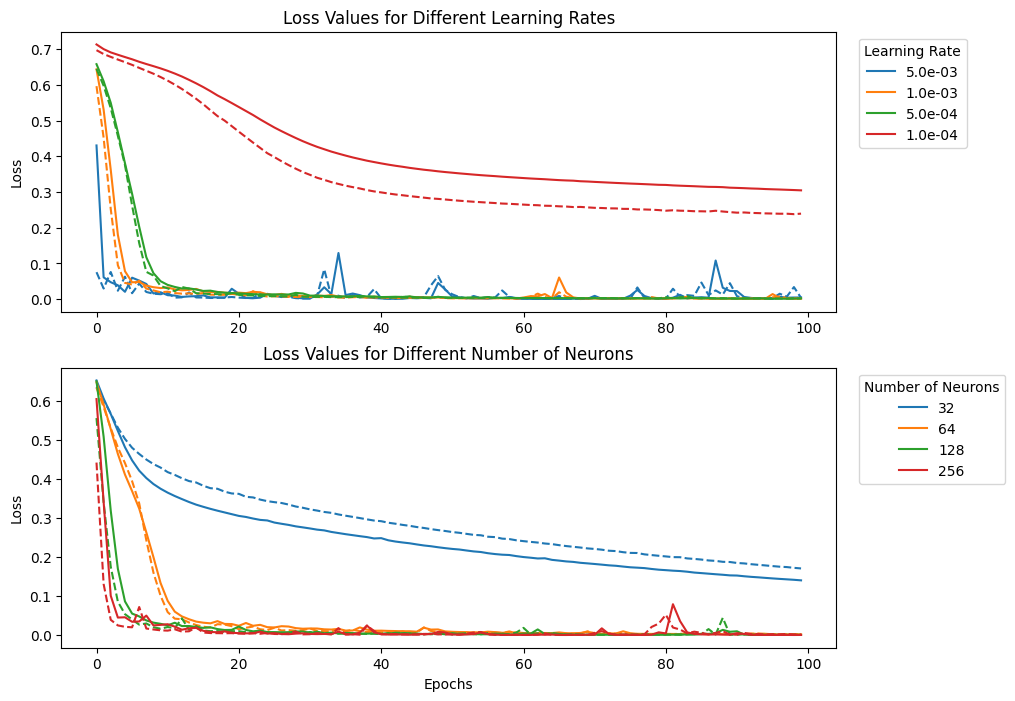

In [ ]:
def NN_model(neurons):

    model = Sequential([
        Flatten(),
        Dense(neurons, input_dim = X_train.shape[1], activation='relu'),  # Input layer
        Dense(neurons//2 , activation='relu'),  # 1 Hidden layer
        Dense(neurons//4 , activation='relu'),  # 2 Hidden layer
        Dense(neurons//6 , activation='relu'),  # 3 Hidden layer
        Dense(neurons//8 , activation='relu'),  # 4 Hidden layer
        Dense(1, activation='sigmoid')  # Output layer for binary classification
    ])

    return model

numNeurons = [32, 64, 128, 256]#64
learningRate = [5e-3,  1e-3, 5e-4, 1e-4] # 5e-4
epochs = 100

history_dict_lr  = {}
history_dict_neurons = {}

################## this is for training the model with one set of parameters. So one learning rate (1e-4) and one number of neuron (64) ##################
# model = NN_model(64) 
# model.compile(optimizer = Adam(learning_rate=learningRate[2]), loss='binary_crossentropy', metrics=['accuracy'])

# # Train the model
# trained_model = model.fit(
#     X_train, y_train,
#     validation_data=(X_val, y_val),  # Use validation set to monitor performance
#     epochs=epochs,
#     batch_size=32,
#     verbose=1
# )

################## this is for traing the model with multiple paramters. So learning rate could be (1e-3,1e-4,....) and number of neurons could be (32,64,128,256...)##################
for learning_rate  in learningRate:

    model = NN_model(64)
    model.compile(optimizer = Adam(learning_rate=learning_rate), loss='binary_crossentropy', metrics=['accuracy'])

    # Train the model
    trained_model = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),  # Use validation set to monitor performance
        epochs=epochs,
        batch_size=32,
        verbose=1
    )

    history_dict_lr[learning_rate] = trained_model.history

for num_neurons  in numNeurons:

    model = NN_model(num_neurons)
    model.compile(optimizer = Adam(learning_rate=5e-4), loss='binary_crossentropy', metrics=['accuracy'])

    # Train the model
    trained_model = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),  # Use validation set to monitor performance
        epochs=epochs,
        batch_size=32,
        verbose=1
    )

    history_dict_neurons[num_neurons] = trained_model.history

fig, axes = plt.subplots(2,1, figsize=(10,8))
#plt.figure(figsize=(10, 6))
colors = plt.cm.tab10

for i, (lr, history) in enumerate(history_dict_lr.items()):
    color = colors(i % 10)
    axes[0].plot(history['loss'], label=f'{lr:.1e}', linestyle='-', color=color)
    axes[0].plot(history['val_loss'], linestyle='--', color=color)

axes[0].set_title('Loss Values for Different Learning Rates')
axes[0].legend(bbox_to_anchor = (1.02, 1), loc='upper left', title='Learning Rate')
axes[0].set_ylabel('Loss')
#axes[0].grid(True)

for i, (neurons, history) in enumerate(history_dict_neurons.items()):
    color = colors(i % 10)
    axes[1].plot(history['loss'], label=f'{neurons}', linestyle='-', color=color)
    axes[1].plot(history['val_loss'], linestyle='--', color=color)

axes[1].set_title('Loss Values for Different Number of Neurons')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend(bbox_to_anchor = (1.02, 1), loc='upper left', title= 'Number of Neurons')
#axes[1].grid(True)

# plt.show()
# plt.ylabel('Loss')

# Evaluate the model on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_accuracy:.4f}")

In [37]:
test_loss_classical_binary, test_acc_classical_binary = model.evaluate(X_test, y_test, verbose=1)

predictions = model.predict(X_test)
predicted_labels = (predictions >= 0.5).astype(int)

recall = recall_score(y_test, predicted_labels)
f1 = f1_score(y_test, predicted_labels)
precision, recall, thresholds = precision_recall_curve(y_test, predictions)
precision_printed = precision_score(y_test, predicted_labels)
cm = confusion_matrix(y_test, predicted_labels)
roc_auc = roc_auc_score(y_test, predicted_labels)

print(len(y_test))

history = trained_model.history
train_loss = history['loss']
val_loss = history['val_loss']

print(f"Precision: {np.mean(precision_printed):.4f}")
print(f"Recall: {np.mean(recall):.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC: {roc_auc:.4f}")
print(f"Confusion Matrix : {cm}")

print(f'Classical model (binary) test accuracy: {test_acc_classical_binary:.4f}')
print(f"X_train shape: {X_train.shape}")


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9973 - loss: 0.0223     
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
197
Precision: 0.9870
Recall: 0.9888
F1-Score: 0.9935
ROC-AUC: 0.9959
Confusion Matrix : [[120   1]
 [  0  76]]
Classical model (binary) test accuracy: 0.9949
X_train shape: (772, 4)


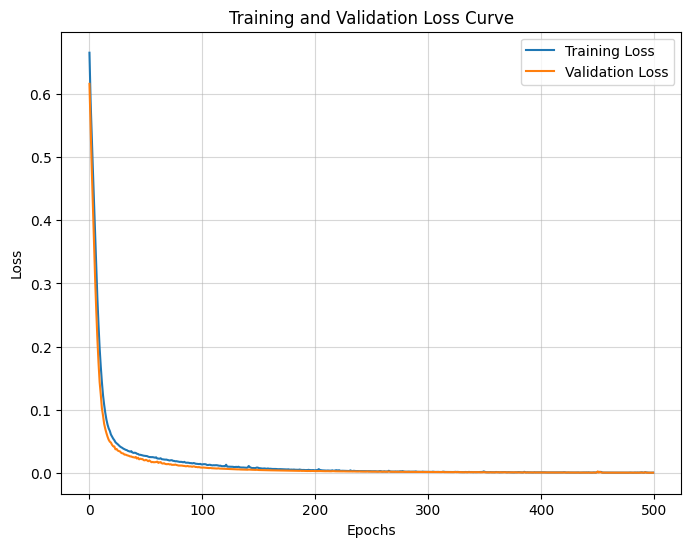

In [69]:
plt.figure(figsize=(8, 6))
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Curve')
plt.legend()
plt.grid(alpha=0.5)
plt.show()

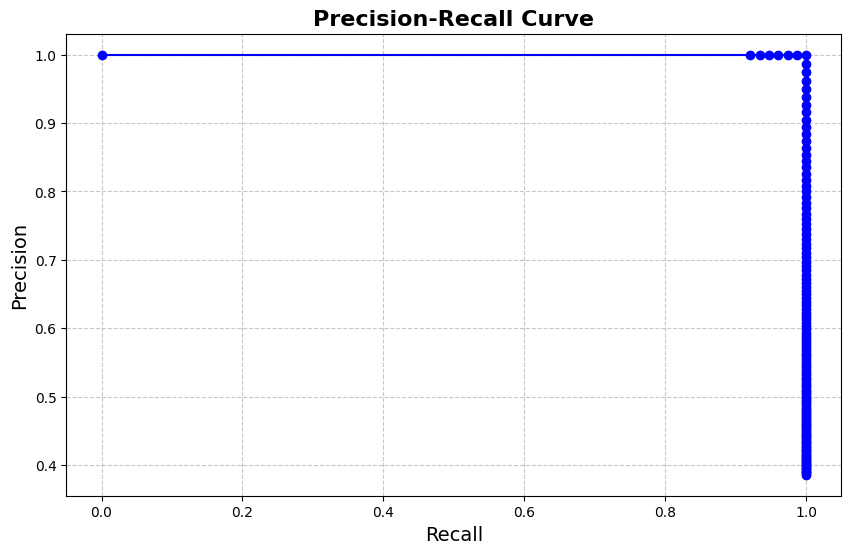

In [59]:
plt.figure(figsize=(10, 6))
plt.plot(recall, precision, marker='o', linestyle='-', color='b')
plt.title('Precision-Recall Curve', fontsize=16, fontweight='bold')
plt.xlabel('Recall', fontsize=14)
plt.ylabel('Precision', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

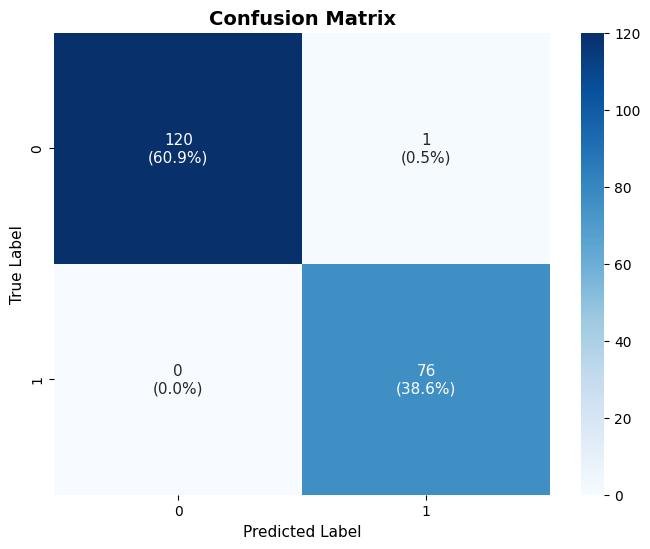

In [67]:
cm_sum = np.sum(cm)  # Total number of samples
cm_percentages = cm / cm_sum * 100  # Calculate percentages

annot = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{cm[i, j]}\n({cm_percentages[i, j]:.1f}%)"

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=annot, fmt="", cmap="Blues", cbar=True, annot_kws={"size": 11})
plt.xlabel("Predicted Label", fontsize=11)
plt.ylabel("True Label", fontsize=11)
plt.title("Confusion Matrix", fontsize=14, fontweight='bold')
plt.show()